# Flower Classification with TensorFlow

This notebook demonstrates how to load the `tf_flowers` dataset, preprocess the images, and train a Convolutional Neural Network (CNN) to classify them.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

c:\Users\Yugesh\anaconda3\envs\tf_gpu_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\Yugesh\anaconda3\envs\tf_gpu_env\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 1. Load Dataset
We use `tensorflow_datasets` to load the flower images. We split the data into 80% for training and 20% for testing.

In [2]:
# Load dataset with an 80/20 split
(ds_train, ds_test), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

num_classes = ds_info.features["label"].num_classes
class_names = ds_info.features["label"].names

print("Classes:", class_names)

c:\Users\Yugesh\anaconda3\envs\tf_gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 100%|██████████| 1/1 [00:41<00:00, 41.80s/ url]


Dataset tf_flowers downloaded and prepared to C:\Users\Yugesh\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.
Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


## 2. Visualize Samples
Let's look at the first 9 images from the training set to understand our data.

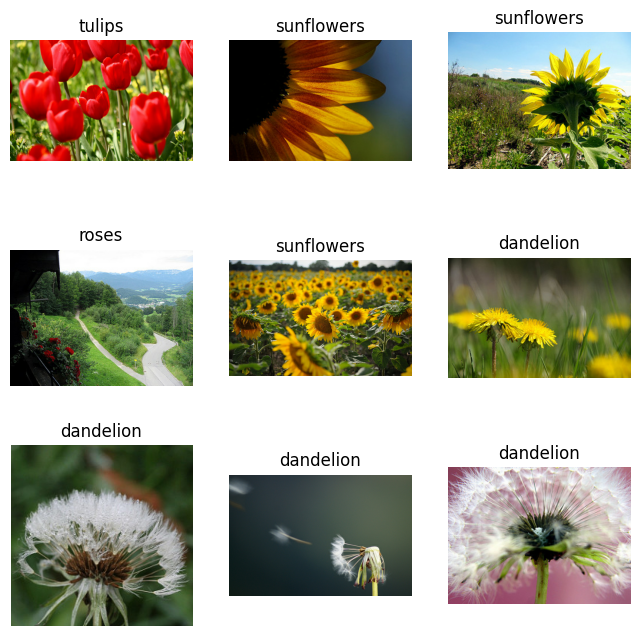

In [3]:
plt.figure(figsize=(8,8))

for i, (img, label) in enumerate(ds_train.take(9)):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.show()

## 3. Preprocessing
We need to standardise the input data:
1.  **Resize**: All images must be the same size ($128 \times 128$) for the CNN.
2.  **Normalize**: Pixel values are scaled from $[0, 255]$ to $[0, 1]$.
3.  **Pipeline**: We apply shuffling, batching, and prefetching to optimize training speed.

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

# Apply preprocessing to training data
train_ds = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Apply preprocessing to test data (no shuffling needed)
test_ds  = ds_test.map(preprocess).batch(BATCH_SIZE)

## 4. Build the CNN Model
We will build a Sequential model consisting of:
* 3 Convolutional blocks (Conv2D + MaxPooling)
* Flatten layer
* Dense layers for classification



In [5]:
model = tf.keras.Sequential([
    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
    tf.keras.layers.MaxPooling2D(),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Classifier Head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

## 5. Train the Model

In [6]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
92/92 [==============================] - 16s 70ms/step - loss: 1.3576 - accuracy: 0.4118 - val_loss: 1.1159 - val_accuracy: 0.5286
Epoch 2/10
92/92 [==============================] - 4s 43ms/step - loss: 1.1011 - accuracy: 0.5616 - val_loss: 0.9985 - val_accuracy: 0.6008
Epoch 3/10
92/92 [==============================] - 4s 43ms/step - loss: 0.9490 - accuracy: 0.6349 - val_loss: 0.8672 - val_accuracy: 0.6580
Epoch 4/10
92/92 [==============================] - 4s 43ms/step - loss: 0.8367 - accuracy: 0.6788 - val_loss: 0.9101 - val_accuracy: 0.6226
Epoch 5/10
92/92 [==============================] - 4s 42ms/step - loss: 0.6881 - accuracy: 0.7313 - val_loss: 0.8224 - val_accuracy: 0.6812
Epoch 6/10
92/92 [==============================] - 4s 42ms/step - loss: 0.5484 - accuracy: 0.7909 - val_loss: 0.8762 - val_accuracy: 0.6757
Epoch 7/10
92/92 [==============================] - 4s 42ms/step - loss: 0.3905 - accuracy: 0.8549 - val_loss: 0.9413 - val_accuracy: 0.6689
Epoch 8/10
9

## 6. Evaluate Performance
We plot the accuracy and loss over epochs to check for overfitting or underfitting.

The first history (The Variable): When you run history = model.fit(...)  
The second .history (The Attribute): Inside that returned object, there is a built-in Python dictionary named history.

In [9]:
# Get the metrics from the final epoch
final_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# Print the results
print("=== Final Training Results ===")
print(f"Training Accuracy:   {final_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss:       {final_loss:.4f}")
print(f"Validation Loss:     {final_val_loss:.4f}")

=== Final Training Results ===
Training Accuracy:   0.9561
Validation Accuracy: 0.6717
Training Loss:       0.1383
Validation Loss:     1.2600


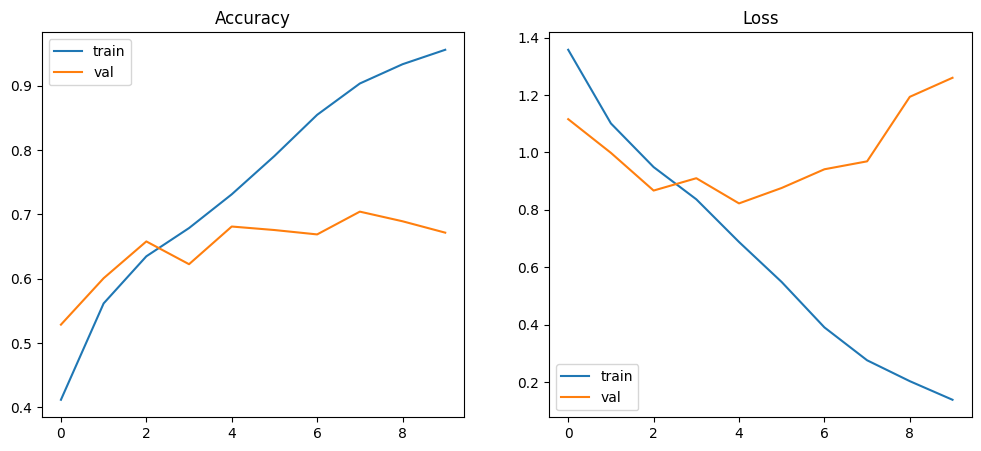

In [7]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

## 7. Prediction Demo
Finally, we take a batch from the test set and visualize the model's predictions vs the true labels.

1/1 [==============================] - 0s 23ms/step


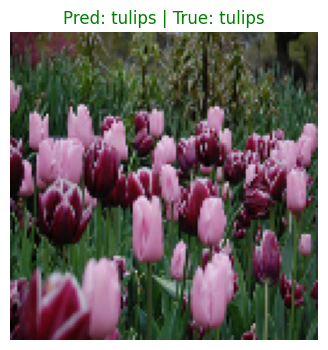

In [11]:
# 1. Get a batch of images
for images, labels in test_ds.take(1):
    preds = model.predict(images)

# 2. Select just the first image (index 0)
i = 1
img = images[i]
label = labels[i]
prediction = preds[i]

# 3. Plot it
plt.figure(figsize=(4,4))

plt.imshow(img)

pred_label = class_names[tf.argmax(prediction)]
true_label = class_names[label]

# Green title if correct, red if incorrect
color = 'green' if pred_label == true_label else 'red'

plt.title(f"Pred: {pred_label} | True: {true_label}", color=color)
plt.axis("off")

plt.show()